# Table of Contents

1. [Basic Interface](#1-basic-interface)
   - 1.1 [Integrators](#11-integrators)
   - 1.2 [Event Handling](#12-event-handling)
   - 1.3 [Integration History](#13-integration-history)
     - 1.3.1 [Example: Simple Harmonic Oscillator](#131-example-simple-harmonic-oscillator)
     - 1.3.2 [Integration Output](#132-integration-output)
   - 1.4 [Advanced Event Handling](#14-advanced-event-handling)
   - 1.5 [Higher Numerical Precision](#15-higher-numerical-precision)
     - 1.5.1 [long double Precision](#151-long-double-precision)
     - 1.5.2 [Arbitrary Precision](#152-arbitrary-precision)
2. [Symbolic API](#2-symbolic-api)
   - 2.1 [OdeSystem Class](#21-odesystem-class)
   - 2.2 [Symbolic Events](#22-symbolic-events)
3. [Lyapunov Exponents](#3-lyapunov-exponents)
   - 3.1 [The Lorenz System](#31-the-lorenz-system)
   - 3.2 [Comparing Chaotic vs Stable Systems](#32-comparing-chaotic-vs-stable-systems)
4. [Parallel Integration](#4-Parallel-Integration)

# 1. Basic Interface

## 1.1 Integrators

The API of **OrbiDyn** provided several integration classes that, once instantiated, can be advanced in time without storing any integration history, but only update their internal state at each step. This is useful for applications where the integration history is not needed, and only the final state of the system is of interest.

In [1]:
from orbidyn import *

def rhs(t, y, omega):
    # ODE for a simple harmonic oscillator
    return [y[1], -omega**2 * y[0]]

# define a solver with omega = 2*pi (period = 1), with strict tolerances for automatic step size control
solver = RK45(rhs, t0=0, q0=[2, 0], rtol=1e-10, atol=1e-10, direction=1, args=(2*np.pi,))

solver.advance_until(100.5) # advance the solver until t=100.5

print(f"Final time: {solver.t}")
print(f"Final state: {solver.q}")

Final time: 100.5
Final state: [-1.99999998e+00  8.61506858e-09]


The **solver** object has several usedul methods, such as `solver.reset()` to reset to its initial state, or `solver.set_ics()` to set new initial conditions.
All methods are inherited from the `OdeSolverView` and `OdeSolver` classes.

In [2]:
solver.set_ics(t0=0, q0=[1, 1]) # set new initial conditions
solver.advance_until(10.25) # advance the solver until t=10

new_solver = solver.copy() # create a copy of the solver
solver.reset() # reset the solver to its initial state

print(f"solver: time: {solver.t}, state: {solver.q}")
print(f"new_solver: time: {new_solver.t}, state: {new_solver.q}")

solver: time: 0.0, state: [1. 1.]
new_solver: time: 10.25, state: [ 0.15915494 -6.2831853 ]


## 1.2 Event Handling

Some applications require the integration to detect when a certain event occurs, such as when a particle crosses a certain surface, or more generally when a certain condition is met.

One such example is the crossing of Poincaré sections, which are used to study the dynamics of a system by looking at the intersections of its trajectory with a lower-dimensional subspace.

Suppose we want to see when a particle moving in the 2D space crosses the `y = 0.7` and `y = 0.95` surfaces. We can define event functions that return the value of `y - 0.7` and `y - 0.95`, and the integrator will detect when these functions change sign, indicating that the particle has crossed the surfaces.

For a potential
$$ V(x, y) = \frac{1}{2} \omega^2 (x^2 + y^2) + \epsilon x y^2 $$
the equations of motion are given by
$$ \ddot{x} = -\omega^2 x - \epsilon y^2 $$
$$ \ddot{y} = -\omega^2 y - 2 \epsilon x y $$

We want to detect each crossing of the `y = 0.7` and `y = 0.95` surfaces that occurs in the positive `y` direction (with $\dot{y} > 0$)

For such physics problems, it is ofter useful to declare a class that extends the interface of the desired inegrator:

In [3]:
from orbidyn import *

class Particle(RK45):

    @property
    def x(self):
        return self.q[0]

    @property
    def y(self):
        return self.q[1]

    @property
    def vx(self):
        return self.q[2]

    @property
    def vy(self):
        return self.q[3]


def rhs(t, q, omega, epsilon):
    x, y, vx, vy = q
    dxdt = vx
    dydt = vy
    dvxdt = -omega**2 * x - epsilon * y**2
    dvydt = -omega**2 * y - 2 * epsilon * x * y
    return [dxdt, dydt, dvxdt, dvydt]

def objective_function_1(t, q, omega, epsilon):
    y = q[1]
    return y - 0.7 # event occurs when y crosses 0.7

def objective_function_2(t, q, omega, epsilon):
    y = q[1]
    return y - 0.95 # event occurs when y crosses 0.95

omega, epsilon = 2*np.pi, 0.1

event_1 = PreciseEvent("crossing_1", objective_function_1, direction=1, event_tol=0.) # event_tol = 0. for detecting the event at machine precision
event_2 = PreciseEvent("crossing_2", objective_function_2, direction=1, event_tol=0.) # event_tol = 0. for detecting the event at machine precision

particle = Particle(rhs, t0=0, q0=[2, 1.1, -0.2, 1], rtol=1e-10, atol=1e-10, direction=1, args=(omega, epsilon), events=[event_1, event_2])

# Let's integrate until the first occurence:
particle.advance_to_event("crossing_1") # passing the name of the desired event, or leave it empty (stop at any event that occurs)
print(f"The y = 0.7 event occurred at t = {particle.t}, state = {particle.q}")
particle.advance_to_event("crossing_2")
print(f"Next, the y = 0.95 event occurred at t = {particle.t}, state = {particle.q}")

The y = 0.7 event occurred at t = 0.881800584780092, state = [1.49410832 0.7        8.36062713 5.44844882]
Next, the y = 0.95 event occurred at t = 0.9362599816661981, state = [1.85387758 0.95       4.72221159 3.64163436]


For a more fine control over the integration process, we can advance each step in a loop, but the Python overhead of such a loop defeats the purpose of using a compiled library:

In [4]:
particle.reset() # reset the particle to its initial state

while not particle.at_event("crossing_1"):
    particle.advance() # single step with step size controlled by the tolerances

t_event = particle.t
event_state = particle.q
print(f"The y = 0.7 event occurred at                   t = {particle.t}, state = {particle.q}")

particle.reset()
particle.advance_until(t_event) # advance until the time of the event, without using the event detection mechanism
print(f"If we try to advance until the detection time without using the event detection mechanism,\nthe particle lands exactly at the same state:   t = {particle.t}, state = {particle.q}")

if (particle.t == t_event) and np.all(particle.q == event_state):
    print("The two states are identical, as expected.")
else:
    print("The two states are NOT identical, something went wrong.")

The y = 0.7 event occurred at                   t = 0.881800584780092, state = [1.49410832 0.7        8.36062713 5.44844882]
If we try to advance until the detection time without using the event detection mechanism,
the particle lands exactly at the same state:   t = 0.881800584780092, state = [1.49410832 0.7        8.36062713 5.44844882]
The two states are identical, as expected.


## 1.3 Integration History

In many cases, we need the entire (or part of) the solution of an ODE, over an interval.
For this purpose, the `LowLevelODE` class is provided:

### 1.3.1 Example: Simple Harmonic Oscillator

Final time: 7.0
Final state: [ 3.0000000e+00 -7.4800327e-10]
Object oscillating between -2.9999999670124957 and 3.0


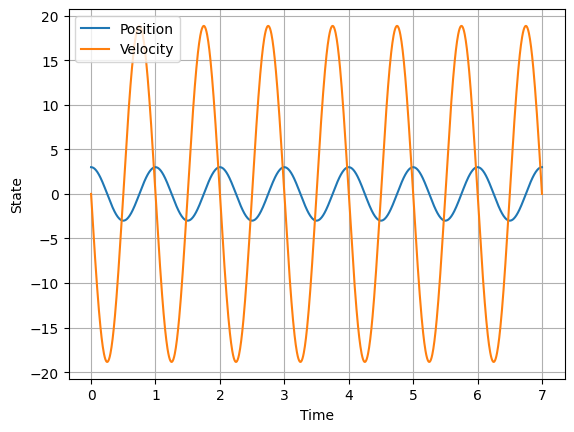

In [5]:
from orbidyn import *
import matplotlib.pyplot as plt

def rhs(t, y, omega):
    # ODE for a simple harmonic oscillator
    x, v = y
    return [v, -omega**2 * x]

# define a solver with omega = 2*pi (period = 1), with strict tolerances for automatic step size control
ode = LowLevelODE(rhs, t0=0, q0=[3, 0], rtol=1e-10, atol=1e-10, direction=1, args=(2*np.pi,), method='RK45')

ode.integrate_until(5) # integrate until t=5
ode.integrate(2) # integrate for 2 more time units, until t=7

t_array = ode.t
state_array = ode.q
x_array = state_array[:, 0]
v_array = state_array[:, 1]

print(f"Final time: {t_array[-1]}")
print(f"Final state: {state_array[-1]}")

print(f"Object oscillating between {x_array.min()} and {x_array.max()}")

fig, ax = plt.subplots()
ax.plot(t_array, state_array[:, 0], label='Position')
ax.plot(t_array, state_array[:, 1], label='Velocity')
ax.set_xlabel('Time')
ax.set_ylabel('State')
ax.legend()
ax.grid()

We can always extract a copy of the `ode` or the `ode`'s internal solver object, and do what we want with them without affecting the state of the `ode` object:

In [6]:
ode_copy: LowLevelODE = ode.copy() # create a copy of the ode object
solver_copy: RK45 = ode.solver()

ode_copy.reset() # reset the copy, leaving the original `ode` object unaffected
solver_copy.reset()

print(f"`ode_copy` type: {type(ode_copy)}")
print(f"`solver_copy` type: {type(solver_copy)}")

`ode_copy` type: <class 'orbidyn.lowlevelode.LowLevelODE'>
`solver_copy` type: <class 'orbidyn.integrators.RK45'>


### 1.3.2 Integration Output

In each `ode.integrate()` call, the `ode` object not only stores integration history, but also returns an `OdeResult` object that contains integration data for that integration interval:

In [7]:
from orbidyn import *

def rhs(t, y, omega):
    # ODE for a simple harmonic oscillator
    x, v = y
    return [v, -omega**2 * x]

# define a solver with omega = 2*pi (period = 1), with strict tolerances for automatic step size control
ode = LowLevelODE(rhs, t0=0, q0=[3, 0], rtol=1e-10, atol=1e-10, direction=1, args=(2*np.pi,), method='RK45')

ode.integrate_until(5) # integrate until t=5, do not retrieve the result

ode_result: OdeResult = ode.integrate(3) # integrate for 3 more time units, until t=8, and retrieve the result

print(f"`ode` object has stored data between {ode.t[0]} and {ode.t[-1]}")
print(f"`ode_result` object has stored data between {ode_result.t[0]} and {ode_result.t[-1]}")
print(f"Success ? : {ode_result.success}")
print("----------------------")
ode_result.examine()

`ode` object has stored data between 0.0 and 8.0
`ode_result` object has stored data between 5.0 and 8.0
Success ? : True
----------------------


=============== OdeResult ===============
	Points           : 561
	Diverges         : false
	Success          : true
	Runtime          : 0.0054211
	Termination cause: t-goal
	Events:
	----------

	----------


## 1.4 Advanced Event Handling

One way to model discontinuous events, where we require that the state of the solution changes abruptly when an event occurs, is by defining a *mask* function that modifies the state of the system when an event is detected. This is useful for modeling systems with impacts, switches, or other discontinuous behaviors.

For example, we can model a bouncing ball by assuming that at each impact with the ground, the vertical velocity of the ball is reversed and reduced by a coefficient of restitution. We can define an event function that detects when the ball hits the ground (when its height is zero), and a mask function that modifies the vertical velocity accordingly.

All bounced close to the ground (h=0): True


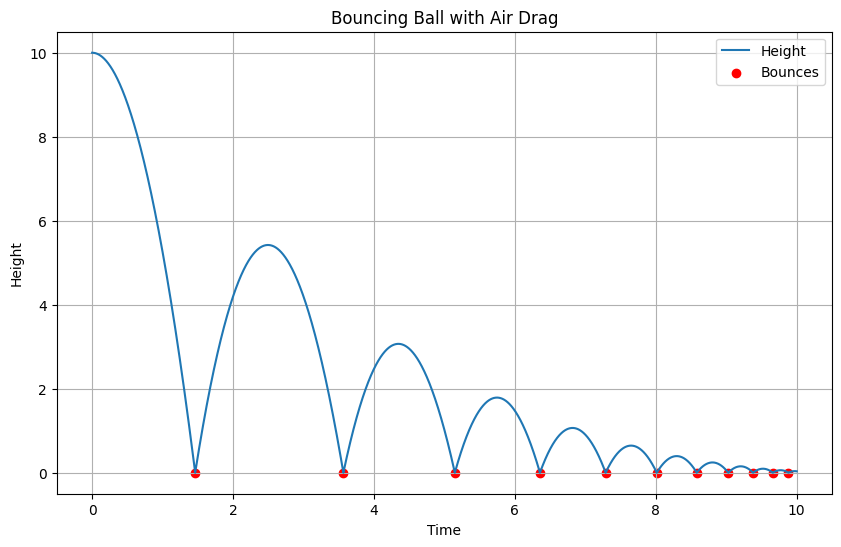

In [8]:
from orbidyn import *
import matplotlib.pyplot as plt


def ode_rhs(t, q, k, g):
    # k: drag coefficient, g: gravity acceleration
    h, v = q #height, velocity
    return [v, -g - k*v]

def ground_hit_function(t, q, k, g):
    h, v = q
    return h # event occurs when h crosses 0

def ground_hit_mask(t, q, k, g):
    h, v = q
    return [0, -0.8*v] # set h=0 exactly, reverse velocity with 80% restitution

ground_hit_event = PreciseEvent(
    name="ground_hit",
    when=ground_hit_function,
    direction=-1,               # Only when falling (h going from + to -)
    mask=ground_hit_mask,          # Set h=0 exactly, reverse velocity with 80% restitution
    event_tol=1e-12
)


# define a solver with omega = 2*pi (period = 1), with strict tolerances for automatic step size control
air_drag_coef = 0.1
gravity_accel = 9.81
ode = LowLevelODE(ode_rhs, t0=0, q0=[10, 0], rtol=1e-10, atol=1e-10,
                  max_step=0.001, # limit the maximum step to detect all bounces, otherwise the solver may skip over the event
                  direction=1,
                  args=(air_drag_coef, gravity_accel),
                  events=[ground_hit_event],
                  method='RK45')

ode_result = ode.integrate_until(10) # integrate until t=10

t_bounce, q_bounce = ode_result.event_data("ground_hit")
h_bounce, v_bounce = q_bounce[:, 0], q_bounce[:, 1]

print(f"All bounced close to the ground (h=0): {np.allclose(h_bounce, 0, atol=1e-6)}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ode_result.t, ode_result.q[:, 0], label='Height')
ax.scatter(t_bounce, h_bounce, color='red', label='Bounces')
ax.legend()
ax.set_xlabel('Time')
ax.set_ylabel('Height')
ax.set_title('Bouncing Ball with Air Drag')
ax.grid()

## 1.5 Higher Numerical Precision

### 1.5.1 long double Precision

For cases where the numerical precision is critical, or many digits of precision are required, solvers can be instantiated with different types besides `double` (the equivalent of the common `float` in Python). In particular: # bullet points now
- `scalar_type = "float"` (float32, single precision)
- `scalar_type = "double"` (float64, double precision, default)
- `scalar_type = "long_double"` (extended precision, if supported by the platform)
- `scalar_type = "mpreal"` (arbitrary precision, using the MPFR library)

In the following example, the tolerances are set to very small values. The RK45 solver is not able to advance the solution in a feasible time, as the accuracy of the internal computations that automate the stepsize is limited by the precision of the floating point type.

Choosing the `long double` type allows the solver to advance the solution in a reasonable time, while achieving the desired accuracy.

In [9]:
from orbidyn import *

def rhs(t, y, omega):
    # ODE for a simple harmonic oscillator
    return [y[1], -omega**2 * y[0]]

# define a solver with omega = 2*pi (period = 1), with strict tolerances for automatic step size control
solver = RK45(rhs, t0=0, q0=[2, 0], rtol=1e-25, atol=1e-25,
              direction=1,
              args=(2*np.pi,),
              scalar_type="long double") # use higher precision

# Integrate for one oscillation period, should only take some seconds with `long double` and `rtol=1e-25`, `atol=1e-25`
solver.advance_until(1)
print(f"Final time: t = {solver.t} reached")
print(f"Reseting the solver to its initial state...")
solver.reset()

# Count integration time units within 100000 steps
for i in range(100000):
    solver.advance() # advance one step
print(f"Final time: t = {solver.t} reached after 100000 steps using long double precision")

solver = RK45(rhs, t0=0, q0=[2, 0], rtol=1e-25, atol=1e-25,
              direction=1,
              args=(2*np.pi,),
              scalar_type="double") # use the default precision

# Count integration time units within 100000 steps
for i in range(100000):
    solver.advance() # advance one step
print(f"Final time: t = {solver.t} reached after 100000 steps using *double* precision")

Final time: t = 1.0 reached
Reseting the solver to its initial state...
Final time: t = 0.2986179012726682 reached after 100000 steps using long double precision
Final time: t = 0.00027813501499960864 reached after 100000 steps using *double* precision


Notice how the solver reached a much shorter final time using double precision with the same number of steps!

### 1.5.2 Arbitrary Precision

If even higher precision is required, the `mpreal` type can be used, which allows for arbitrary precision arithmetic using the MPFR library.

The number of bits of precision can be set using `set_mpreal_prec(bits)`, where `bits` is the desired number of bits of precision. This allows for very high precision calculations, at the cost of increased computational time.

As a result, `mpreal` should be used for "short" integration intervals.

In [10]:
from orbidyn import *

def rhs(t, y, omega):
    # ODE for a simple harmonic oscillator
    return [y[1], -omega**2 * y[0]]

# define a solver with omega = 2*pi (period = 1), with strict tolerances for automatic step size control
set_mpreal_prec(256) # set the precision to 256 bits (about 77 decimal digits)
solver = RK45(rhs, t0=0, q0=[2, 0], rtol=1e-25, atol=1e-25,
              direction=1,
              args=(2*np.pi,),
              scalar_type="mpreal") # use higher precision

solver.advance_until(1e-5)
print(f"Final time: t = {solver.t} reached using arbitrary precision (mpreal).")

Final time: t = 1e-05 reached using arbitrary precision (mpreal).


# 2. Symbolic API

## 2.1 OdeSystem Class

The main advantage of using precompiled solvers, is that if we compile the equations of motion in machine code too, we can entirely get rid of any Python overhead, and achieve the best performance possible. All provided classes shown earlier can also be instantiated with function pointers to compiled functions, instead of Python functions. However, this is a bit cumbersome, as it requires the user to write lower level code, compile it, and link it with the Python code. To alleviate this, a symbolic API is provided, that allows the user to define the equations of motion in a symbolic form, and directly instantiate the solvers.

Let's consider the Van der Pol oscillator, and see the speedup we can achieve by using the symbolic API. The equations of motion are given by:

$$\ddot{x} = \mu(1-x^2)\dot{x} - x$$

We can now leverage the lightweight symbolic engine provided by **NumiPhy** (imported from **OrbiDyn**) that has a similar interface to **SymPy**, but is more specialized for our purposes. ODE systems can be instantiated using the `OdeSystem` class, which takes as input a list of symbolic expressions for the right-hand side of the equations of motion, and a list of symbolic variables for the state vector. Once the system is defined, we can extract `OdeSolver` or `LowLevelODE` objects with any initial conditions, and integrate them as before.

In [11]:
from orbidyn import *
from scipy.integrate import solve_ivp # for comparison
import time

# === SYMBOLIC APPROACH ===
t, x, y, mu = symbols('t, x, y, mu')

system_symbolic = OdeSystem(
    ode_sys=[y, mu*(1 - x**2)*y - x],
    t=t,
    q=[x, y],
    args=[mu]
)

# Compiled solver
solver_compiled = system_symbolic.get(
    t0=0, q0=[1.0, 2.0],
    args=(500,),
    method="BDF",  # BDF for stiff problems
    rtol=1e-13, atol=1e-13
)

# === PYTHON FUNCTION APPROACH ===
def van_der_pol(t, q, mu):
    x, y = q
    return np.array([y, mu*(1 - x**2)*y - x])

def van_der_pol_jac(t, q, mu):
    x, y = q
    return np.array([[0, 1], [-2*mu*x*y - 1, mu*(1-x**2)]])

solver_python = LowLevelODE(
    van_der_pol,
    jac=van_der_pol_jac,
    t0=0, q0=[1.0, 2.0],
    args=(500,),
    method="BDF",
    rtol=1e-13, atol=1e-13
)

# Compare performance
print("Integrating from t=0 to t=400...\n")

result_compiled = solver_compiled.integrate(400)
print(f"Compiled (symbolic):  {result_compiled.runtime*1000:.6f} milliseconds, {len(result_compiled.t)} steps")

result_python = solver_python.integrate(400)
print(f"Python functions:     {result_python.runtime*1000:.6f} milliseconds, {len(result_python.t)} steps")

t_start = time.perf_counter()
result_scipy = solve_ivp(van_der_pol, [0, 400], [1.0, 2.0], args=(500,), method="BDF", rtol=1e-13, atol=1e-13)
t_end = time.perf_counter()
print(f"SciPy solve_ivp:      {(t_end - t_start)*1000:.6f} milliseconds, {len(result_scipy.t)} steps")

speedup = result_python.runtime / result_compiled.runtime
speedup_scipy = (t_end - t_start) / result_compiled.runtime
print(f"\nSpeedup: {speedup:.1f}x faster with compiled code!")
print(f"         {speedup_scipy:.1f}x faster than SciPy solve_ivp!")

Compiling...
Compiled binary constructed in 4.44 seconds

Integrating from t=0 to t=400...

Compiled (symbolic):  1.580782 milliseconds, 6135 steps
Python functions:     24.676232 milliseconds, 6138 steps
SciPy solve_ivp:      570.515505 milliseconds, 6126 steps

Speedup: 15.6x faster with compiled code!
         360.9x faster than SciPy solve_ivp!


## 2.2 Symbolic Events

Events can also be defined in a symbolic form, using the `SymbolicPreciseEvent` class. Let's repeat the example of the bouncing ball, but this time using the symbolic API.

Compiling...
Compiled binary constructed in 4.45 seconds



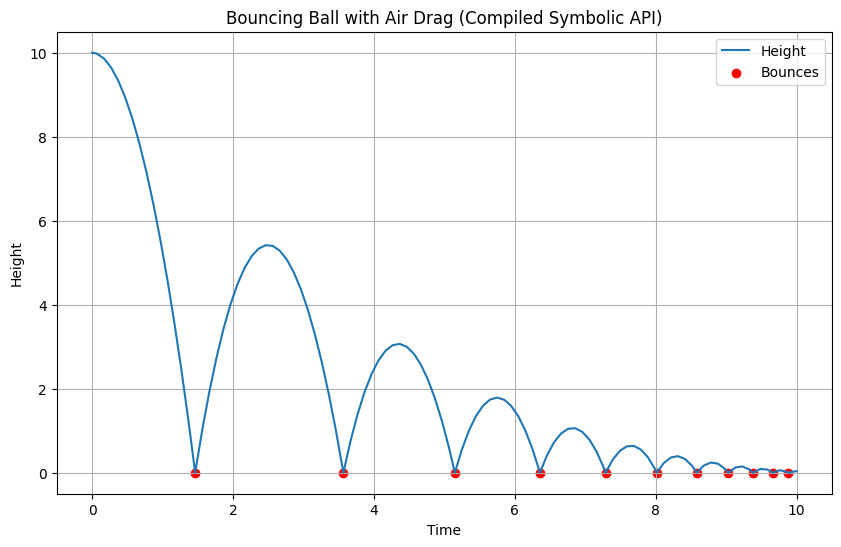

In [12]:
from orbidyn import *
import matplotlib.pyplot as plt

# Bouncing ball with gravity and air resistance
t, h, v, g, k = symbols('t, h, v, g, k')

# Event: ball hits ground (h = 0)
# When h crosses 0 going down, reverse velocity with 80% energy loss
ground_hit = SymbolicPreciseEvent(
    name="ground_hit",
    event=h,                    # Triggers when h = 0
    direction=-1,               # Only when falling (h going from + to -)
    mask=[0, -0.8*v],          # Set h=0 exactly, reverse velocity with 80% restitution
    event_tol=1e-12
)

# Create system: dh/dt = v, dv/dt = -g - k*v (air resistance)
bouncing_ball = OdeSystem(
    ode_sys=[v, -g - k*v], # equations of motion
    t=t, # integration symbol
    q=[h, v], # state vector symbols
    args=[g, k], # parameter symbols
    events=[ground_hit]
)

# Solve with limited max_step to ensure bounces are detected
solver = bouncing_ball.get(
    t0=0, q0=[10.0, 0.0],      # Start at height 10
    args=(9.81, 0.1),          # Gravity and air resistance coefficient
    method="RK45",
    max_step=0.1,               # Limit step size to detect all bounces
    scalar_type="double",        # Use double precision
    rtol=1e-10, atol=1e-10,
    compiled=True # Set to False to use Python functions instead of compiled code (slower, but no compilation overhead)
)

ode_result = solver.integrate(10.0)
t_bounce, q_event = ode_result.event_data('ground_hit')
h_bounce, v_bounce = q_event[:, 0], q_event[:, 1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ode_result.t, ode_result.q[:, 0], label='Height')
ax.scatter(t_bounce, h_bounce, color='red', label='Bounces')
ax.legend()
ax.set_xlabel('Time')
ax.set_ylabel('Height')
ax.set_title('Bouncing Ball with Air Drag (Compiled Symbolic API)')
ax.grid()

# 3. Lyapunov Exponents

The library comes with a built-in implementation of the algorithm for computing Lyapunov exponents, which are used to characterize the chaotic behavior of dynamical systems. This is achieved by integrating the variational equations of the system, which describe how small perturbations to the initial conditions grow or decay over time.

It is recommended to use the symbolic API for this purpose, as it allows for a more efficient computation of the Lyapunov exponents.

## 3.1 The Lorenz System

As an example, we will compute the Lyapunov exponents of the Lorenz system, which is a well-known chaotic system defined by the following equations:

$$\frac{dx}{dt} = \sigma(y - x)$$
$$\frac{dy}{dt} = x(\rho - z) - y$$
$$\frac{dz}{dt} = xy - \beta z$$

where:
- $\sigma = 10$ (Prandtl number)
- $\rho = 28$ (Rayleigh number)
- $\beta = 8/3$ (geometric factor)

With these parameters, the system exhibits chaotic behavior with a positive Lyapunov exponent ($\lambda \approx 0.906$).

Compiling...
Compiled binary constructed in 4.43 seconds

Computing Lyapunov exponents for Lorenz system...


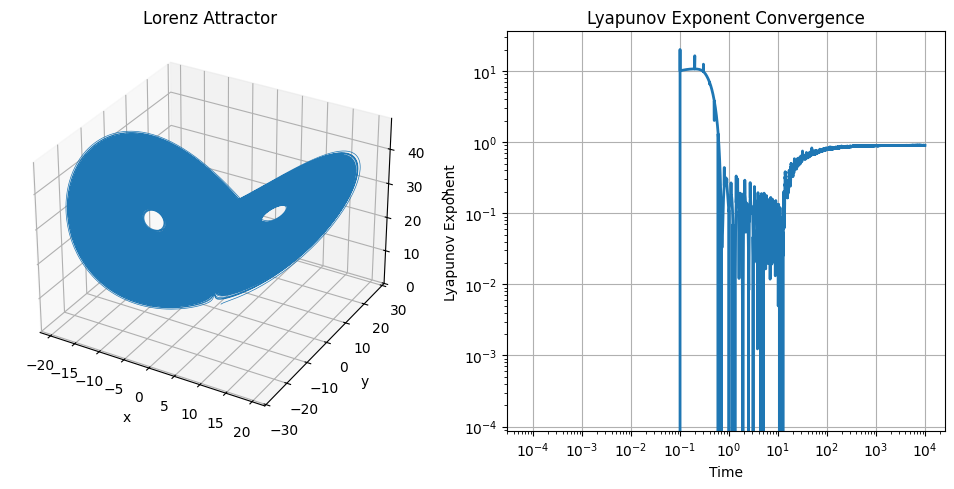


Final Lyapunov exponent: 0.902458
System is chaotic (λ > 0)
Expected for Lorenz: λ ≈ 0.906


In [13]:
from orbidyn import *
import matplotlib.pyplot as plt

t, x, y, z, sigma, rho, beta = symbols('t, x, y, z, sigma, rho, beta')

lorenz = OdeSystem(
    ode_sys=[
        sigma*(y - x),
        x*(rho - z) - y,
        x*y - beta*z
    ],
    t=t,
    q=[x, y, z],
    args=[sigma, rho, beta]
)

# Create variational solver
# q0 needs 2*Nsys elements: first Nsys for base system, last Nsys for variational direction
solver_var = lorenz.get_variational(
    t0=0,
    q0=[1.0, 1.0, 1.0,      # Initial conditions for base system (x, y, z)
        1.0, 0.0, 0.0],     # Variational direction (automatically normalized)
    period=0.1,              # Renormalization period
    args=(10.0, 28.0, 8/3),  # sigma, rho, beta
    method="RK45",
    rtol=1e-9, atol=1e-12,
    scalar_type="long double"
)

# Integrate
print("Computing Lyapunov exponents for Lorenz system...")
result = solver_var.integrate(10000.0)

# Plot Lorenz attractor
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(result.q[:, 0], result.q[:, 1], result.q[:, 2], linewidth=0.5)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title('Lorenz Attractor')

# Plot Lyapunov exponent convergence
ax2 = fig.add_subplot(132)
ax2.loglog(solver_var.t_lyap, solver_var.lyap, linewidth=2)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.set_xlabel('Time')
ax2.set_ylabel('Lyapunov Exponent')
ax2.set_title('Lyapunov Exponent Convergence')
ax2.grid(True)


plt.tight_layout()
plt.show()

lyap_final = solver_var.lyap[-1]
print(f"\nFinal Lyapunov exponent: {lyap_final:.6f}")
print(f"System is {'chaotic (λ > 0)' if lyap_final > 0 else 'stable (λ < 0)'}")
print(f"Expected for Lorenz: λ ≈ 0.906")

## 3.2 Comparing Chaotic vs Stable Systems

For stable systems, we expect the Lyapunov exponent to converge to non-positive values, indicating that small perturbations to the initial conditions decay over time. For example, consider the simple harmonic oscillator defined by the following equations:

Compiling...
Compiled binary constructed in 4.40 seconds

Compiling...
Compiled binary constructed in 4.38 seconds



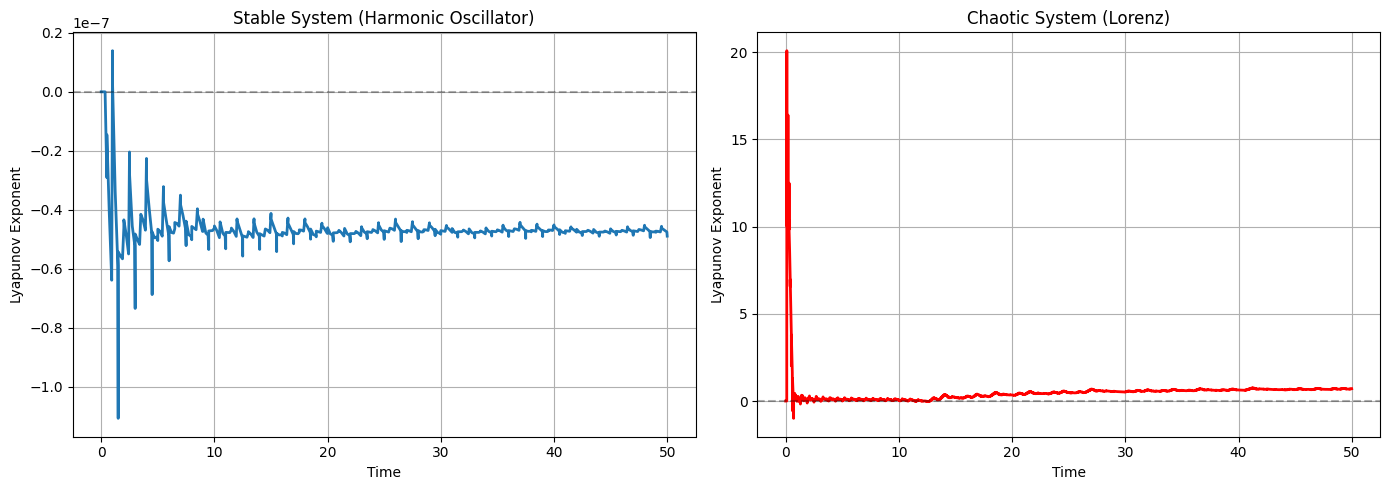

Stable system:  λ(t=50) = -0.000000 (≈ 0)
Chaotic system: λ(t=50) = 0.703754 (> 0)


In [14]:
from orbidyn import *
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

t, x, y, z, sigma, rho, beta, v = symbols('t, x, y, z, sigma, rho, beta, v')

lorenz = OdeSystem(
    ode_sys=[
        sigma*(y - x),
        x*(rho - z) - y,
        x*y - beta*z
    ],
    t=t,
    q=[x, y, z],
    args=[sigma, rho, beta]
)

stable = OdeSystem([v, -x], t, [x, v])

# For 2D system, q0 needs 4 elements: [x0, v0, dx0, dv0]
solver_stable = stable.get_variational(
    t0=0,
    q0=[1.0, 0.0,     # Base system initial conditions
        1.0, 0.0],    # Variational direction
    period=0.5,
    method="RK45"
)
solver_stable.integrate(50.0)

# Chaotic Lorenz (from before)
solver_chaotic = lorenz.get_variational(
    t0=0,
    q0=[1.0, 1.0, 1.0,    # Base system
        1.0, 0.0, 0.0],   # Variational direction
    period=0.1,
    args=(10.0, 28.0, 8/3),
    method="RK45"
)
solver_chaotic.integrate(50.0)

# Compare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1: Axes = axes[0]
ax2: Axes = axes[1]

ax1.plot(solver_stable.t_lyap, solver_stable.lyap, linewidth=2)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.set_xlabel('Time')
ax1.set_ylabel('Lyapunov Exponent')
ax1.set_title('Stable System (Harmonic Oscillator)')
ax1.grid(True)

ax2.plot(solver_chaotic.t_lyap, solver_chaotic.lyap, linewidth=2, color='red')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.set_xlabel('Time')
ax2.set_ylabel('Lyapunov Exponent')
ax2.set_title('Chaotic System (Lorenz)')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Stable system:  λ(t=50) = {solver_stable.lyap[-1]:.6f} (≈ 0)")
print(f"Chaotic system: λ(t=50) = {solver_chaotic.lyap[-1]:.6f} (> 0)")

# 4. Parallel Integration

For applications that require high computational efficiency, parallel integration can be employed to distribute the workload across multiple processors. This approach significantly reduces the time needed when integrating independent systems, such as multiple orbital simulations or large-scale dynamical models.

As an example, suppose we want to draw the Poincaré sections for multiple orbital simulations simultaneously. For a 2D system, we assume the potential of the form
$$ V(x, y) = \frac{1}{2} \omega_x^2 x^2 + \frac{1}{2} \omega_y^2 y^2 + \epsilon\,\, x y^2 $$

which has the corresponding equations of motion:

$$\begin{cases}
\dot{x} = p_x, \\
\dot{y} = p_y, \\
\dot{p_x} = - \omega_x^2 x - \epsilon y^2, \\
\dot{p_y} = - \omega_y^2 y - 2 \epsilon x y.
\end{cases}$$

We will set initial conditions with a common energy $E = \frac{1}{2} \dot{x}_0^2 + \frac{1}{2} \dot{y}_0^2 + V(x_0, y_0) $, with $p_{y,0} > 0$, and mark the Poincaré section at $y = 0, p_y > 0$.

Compiling...
Compiled binary constructed in 4.42 seconds


Parallel integration completed in: 0 h, 0 m, 10 s


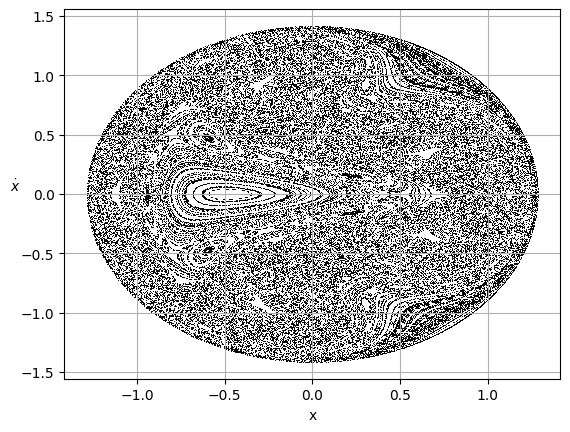

In [15]:
from orbidyn import *
import matplotlib.pyplot as plt


def V(x, y, eps, omega_x, omega_y):
    return 0.5 * omega_x**2 * x**2 + 0.5 * omega_y**2 * y**2 + eps * x * y**2


t, x, y, px, py, eps, omega_x, omega_y = symbols('t, x, y, px, py, eps, omega_x, omega_y')

v = V(x, y, eps, omega_x, omega_y) #symbolic expression from the `Expr` class


state_vector = [x, y, px, py]
ode_rhs = [px,
           py,
           -v.diff(x),
           -v.diff(y)]

event = SymbolicPreciseEvent("poincare", # event name
                             event = y, # event triggered when y = 0
                             direction = 1, # only trigger when y is increasing
                             event_tol = 0) # machine precision tolerance for detecting the event

ode_sys = OdeSystem(ode_rhs, t, state_vector, args=(eps, omega_x, omega_y), events=[event])


E = 1
y0 = 0
xmin, xmax = -1.6, 1.6
N = 30
args = (0.75, 1.1, 1.4) # epsilon, omega_x, omega_y

# The next loop scans a small interval of initial conditions in the (x, x_dot) plane
# with E = 1 and y = 0
orbits: list[LowLevelODE] = []
for i in range(N):
    x0 = xmin + (xmax - xmin) * i / (N - 1)
    for j in range(N):
        pxmin_sqr = 2*(E - V(x0, y0, *args))
        if pxmin_sqr < 0:
            continue
        pxmin = pxmin_sqr**0.5
        pxmax = -pxmin
        px0 = pxmin + (pxmax - pxmin) * j / (N - 1)
        y0 = 0
        py0_sqr = 2*(E - V(x0, y0, *args)) - px0**2
        if py0_sqr < 0:
            continue
        py0 = py0_sqr**0.5
        orbits.append(ode_sys.get(t0=0, q0=[x0, y0, px0, py0], rtol=1e-14, atol=1e-14, args=args, method="BDF"))

# terminate integration when `max_events` number of crossings are detected
event_options = EventOpt("poincare", max_events = 100, terminate=True)

integrate_all(orbits, interval=10000, t_eval=[], event_options=[event_options], threads=4)


# plot in (x, px)
fig, ax = plt.subplots()

ax.grid(True)
for orbit in orbits:
    t_sec, q_sec = orbit.event_data("poincare")

    x_column = q_sec[:, 0]
    px_column = q_sec[:, 2]
    ax.scatter(x_column, px_column, s=0.5, lw=0, c='k')
plt.xlabel('x')
plt.ylabel('$\\dot{x}$', rotation=0)
plt.show()